# 3. Mini Simulation — The Full Loop

This notebook ties everything together: generate a geometry, spawn agents,
and run a multi-step simulation loop with random actions.

**The simulation loop (per timestep):**
1. Build observations for all agents (`crowdrl-core`)
2. Policy produces 4D actions (here: random)
3. Interpret actions → desired velocities + orientations (`crowdrl-core`)
4. Compute contact forces (`crowdrl-core`)
5. Integrate physics (simple Euler)
6. Repeat

In the real system, step 2 will be ONNX inference on a trained policy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
from shapely.geometry import Polygon, Point

from crowdrl_core.action import ActionConfig, interpret_actions_batch
from crowdrl_core.collision import compute_contact_forces, detect_collisions
from crowdrl_core.geometry import build_navmesh, extract_wall_segments, sample_point_in_polygon
from crowdrl_core.observation import ObsConfig, build_observations_batch
from crowdrl_core.world_state import WorldState
from crowdrl_env.geometry_generator import GeometryConfig, GeometryTier, generate_geometry
from crowdrl_env.visualiser import plot_agents, plot_geometry, plot_navmesh

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## Setup: Bottleneck with 15 Agents

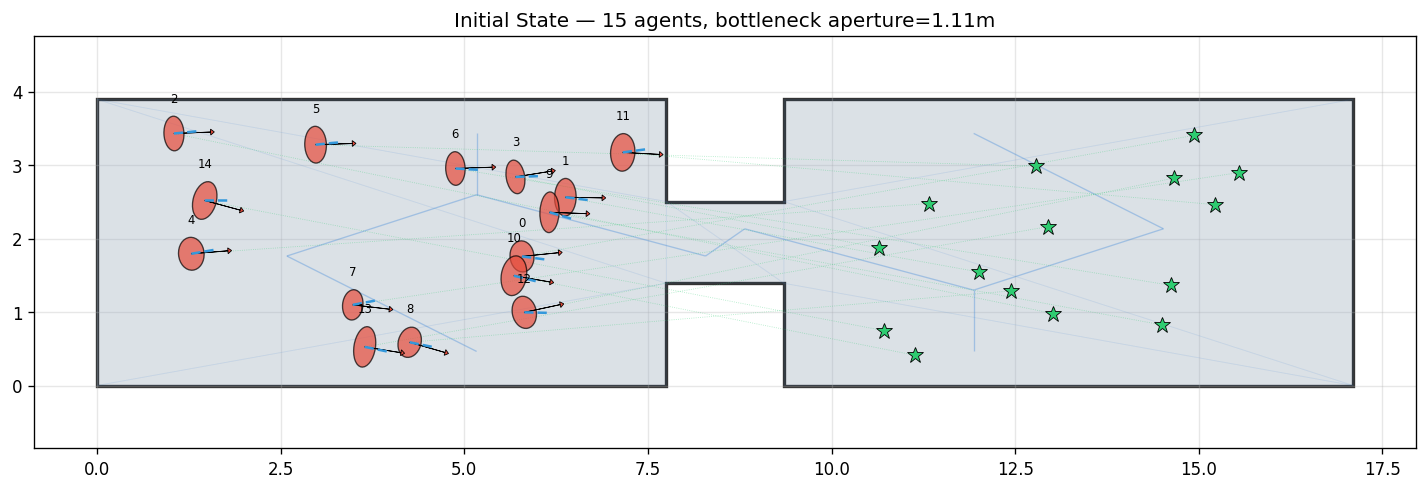

In [2]:
rng = np.random.default_rng(42)

# Generate a bottleneck geometry
geom = generate_geometry(
    np.random.default_rng(7),
    GeometryConfig(
        tier=GeometryTier.TIER_1,
        corridor_width_range=(3.0, 4.0),
        corridor_length_range=(14.0, 18.0),
        bottleneck_aperture_range=(1.0, 1.5),
    ),
)
polygon = geom.polygon
navmesh = build_navmesh(polygon)
wall_segments = extract_wall_segments(polygon)

# Spawn agents
n_agents = 15
positions = np.array([sample_point_in_polygon(geom.spawn_regions[0], rng) for _ in range(n_agents)])
goal_positions = np.array([sample_point_in_polygon(geom.goal_regions[0], rng) for _ in range(n_agents)])

world = WorldState(
    positions=positions,
    velocities=np.zeros((n_agents, 2)),
    torso_orientations=rng.uniform(-0.3, 0.3, n_agents),
    head_orientations=rng.uniform(-0.3, 0.3, n_agents),
    shoulder_widths=rng.uniform(0.20, 0.28, n_agents),
    chest_depths=rng.uniform(0.12, 0.18, n_agents),
    goal_positions=goal_positions,
    walkable_polygon=polygon,
    wall_segments=wall_segments,
    navmesh=navmesh,
)

# Show initial state
fig, ax = plt.subplots(figsize=(12, 5))
plot_geometry(polygon, ax=ax)
plot_navmesh(navmesh, ax, show_adjacency=True, tri_alpha=0.08)
plot_agents(world, ax)
ax.set_title(f"Initial State — {n_agents} agents, bottleneck aperture={geom.metadata.get('aperture', '?'):.2f}m")
plt.tight_layout()
plt.show()

## Run the Simulation

100 timesteps with random actions. This demonstrates the observe → act → update
loop and records trajectories for visualisation.

In [3]:
obs_config = ObsConfig()
action_config = ActionConfig(max_speed=1.2, max_heading_change=np.pi / 6)
dt = 0.1
n_steps = 100

# Record trajectory history
trajectory = np.zeros((n_steps + 1, n_agents, 2))
trajectory[0] = world.positions.copy()

obs_history = []
collision_counts = []

for step in range(n_steps):
    # 1. Observe
    obs = build_observations_batch(world, obs_config)
    obs_history.append(obs)

    # 2. Act (random policy — will be replaced by trained MAPPO)
    raw_actions = rng.uniform(-1, 1, (n_agents, 4))
    # Bias actions toward goal (crude heuristic to make motion interesting)
    goal_dirs = world.goal_positions - world.positions
    goal_angles = np.arctan2(goal_dirs[:, 1], goal_dirs[:, 0])
    heading_errors = goal_angles - world.torso_orientations
    heading_errors = (heading_errors + np.pi) % (2 * np.pi) - np.pi
    raw_actions[:, 0] = 0.5  # moderate speed
    raw_actions[:, 1] = np.clip(heading_errors / action_config.max_heading_change, -1, 1) * 0.7 + raw_actions[:, 1] * 0.3

    # 3. Interpret actions
    results = interpret_actions_batch(
        raw_actions,
        world.torso_orientations,
        world.torso_orientations,
        world.head_orientations,
        action_config,
    )

    # 4. Contact forces
    forces = compute_contact_forces(world)
    collisions = detect_collisions(world)
    collision_counts.append(len(collisions))

    # 5. Integrate
    for i, r in enumerate(results):
        world.velocities[i] = r.desired_velocity + forces[i] * dt
        world.positions[i] += world.velocities[i] * dt
        world.torso_orientations[i] = r.new_torso_orientation
        world.head_orientations[i] = r.new_head_orientation

    # Clamp agents inside polygon (simple boundary enforcement)
    for i in range(n_agents):
        if not polygon.contains(Point(world.positions[i])):
            world.positions[i] = trajectory[step, i]  # revert
            world.velocities[i] = np.zeros(2)

    trajectory[step + 1] = world.positions.copy()

print(f"Simulation complete: {n_steps} steps, dt={dt}s, total time={n_steps * dt:.1f}s")
print(f"Mean collisions per step: {np.mean(collision_counts):.1f}")
print(f"All observations finite: {all(np.all(np.isfinite(o)) for o in obs_history)}")

Simulation complete: 100 steps, dt=0.1s, total time=10.0s
Mean collisions per step: 0.9
All observations finite: True


## Visualise Trajectories

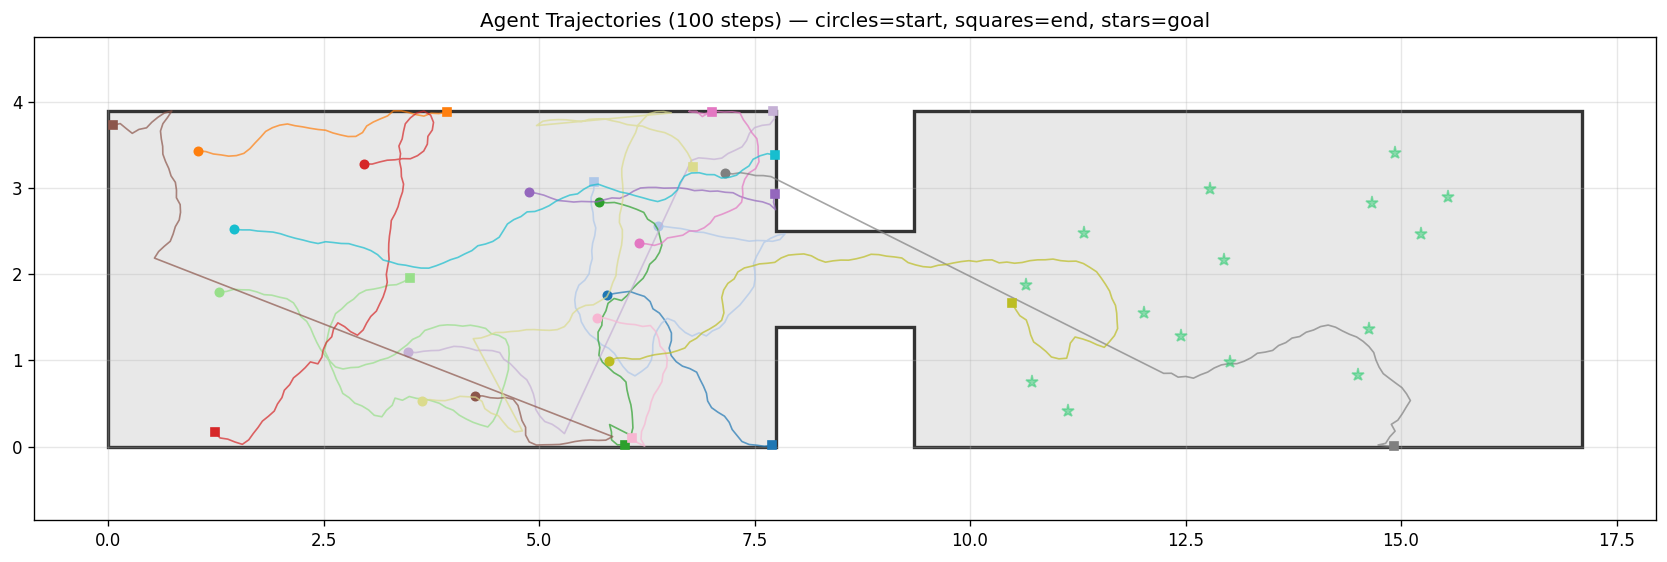

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
plot_geometry(polygon, ax=ax)

cmap = plt.cm.tab20
for i in range(n_agents):
    color = cmap(i / n_agents)
    traj = trajectory[:, i, :]
    ax.plot(traj[:, 0], traj[:, 1], "-", color=color, linewidth=1.0, alpha=0.7)
    ax.plot(traj[0, 0], traj[0, 1], "o", color=color, markersize=5)  # start
    ax.plot(traj[-1, 0], traj[-1, 1], "s", color=color, markersize=5)  # end

# Mark goals
for i in range(n_agents):
    ax.plot(world.goal_positions[i, 0], world.goal_positions[i, 1],
            "*", color="#2ecc71", markersize=8, alpha=0.5)

ax.set_title(f"Agent Trajectories ({n_steps} steps) — circles=start, squares=end, stars=goal")
plt.tight_layout()
plt.show()

## Simulation Snapshots

Show the world state at several timesteps.

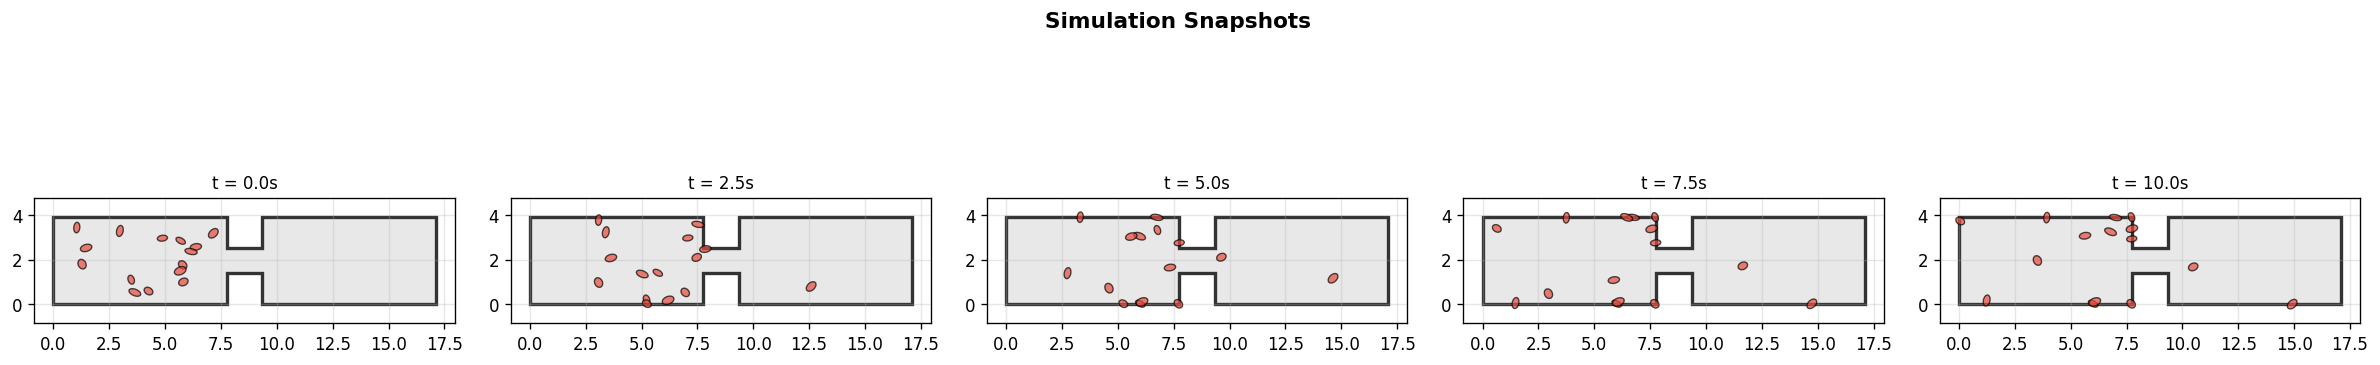

In [5]:
snapshot_steps = [0, 25, 50, 75, 100]

fig, axes = plt.subplots(1, len(snapshot_steps), figsize=(20, 4))

for ax, t in zip(axes, snapshot_steps):
    # Reconstruct world state at this timestep
    snapshot = WorldState(
        positions=trajectory[t].copy(),
        velocities=np.zeros((n_agents, 2)),
        torso_orientations=world.torso_orientations.copy(),
        head_orientations=world.head_orientations.copy(),
        shoulder_widths=world.shoulder_widths,
        chest_depths=world.chest_depths,
        goal_positions=world.goal_positions,
        walkable_polygon=polygon,
        wall_segments=wall_segments,
    )
    plot_geometry(polygon, ax=ax)
    plot_agents(snapshot, ax, show_goals=False, show_orientations=False, show_ids=False)
    ax.set_title(f"t = {t * dt:.1f}s", fontsize=10)

fig.suptitle("Simulation Snapshots", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Collision Statistics

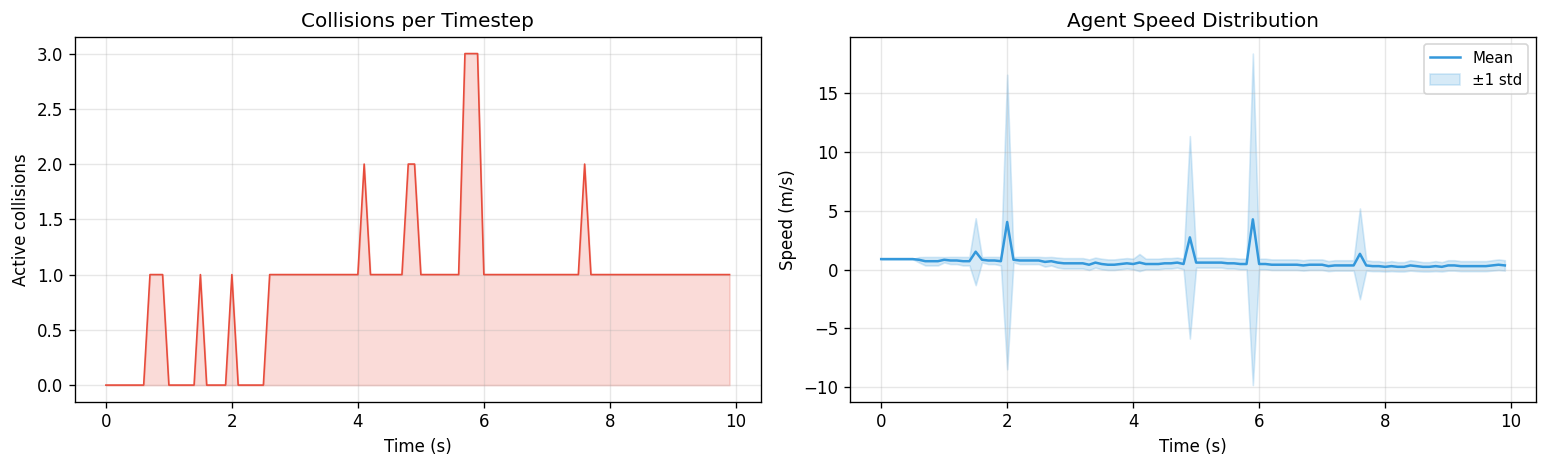

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Collisions over time
axes[0].plot(np.arange(n_steps) * dt, collision_counts, color="#e74c3c", linewidth=1.0)
axes[0].fill_between(np.arange(n_steps) * dt, collision_counts, alpha=0.2, color="#e74c3c")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Active collisions")
axes[0].set_title("Collisions per Timestep")
axes[0].grid(True, alpha=0.3)

# Agent speeds over time
speeds = np.zeros((n_steps, n_agents))
for t in range(n_steps):
    for i in range(n_agents):
        displacement = trajectory[t + 1, i] - trajectory[t, i]
        speeds[t, i] = np.linalg.norm(displacement) / dt

mean_speed = speeds.mean(axis=1)
std_speed = speeds.std(axis=1)
time = np.arange(n_steps) * dt

axes[1].plot(time, mean_speed, color="#3498db", linewidth=1.5, label="Mean")
axes[1].fill_between(time, mean_speed - std_speed, mean_speed + std_speed,
                      alpha=0.2, color="#3498db", label="±1 std")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Speed (m/s)")
axes[1].set_title("Agent Speed Distribution")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Observation Space Heatmap

Visualise how the observation vector varies across agents at a single timestep.

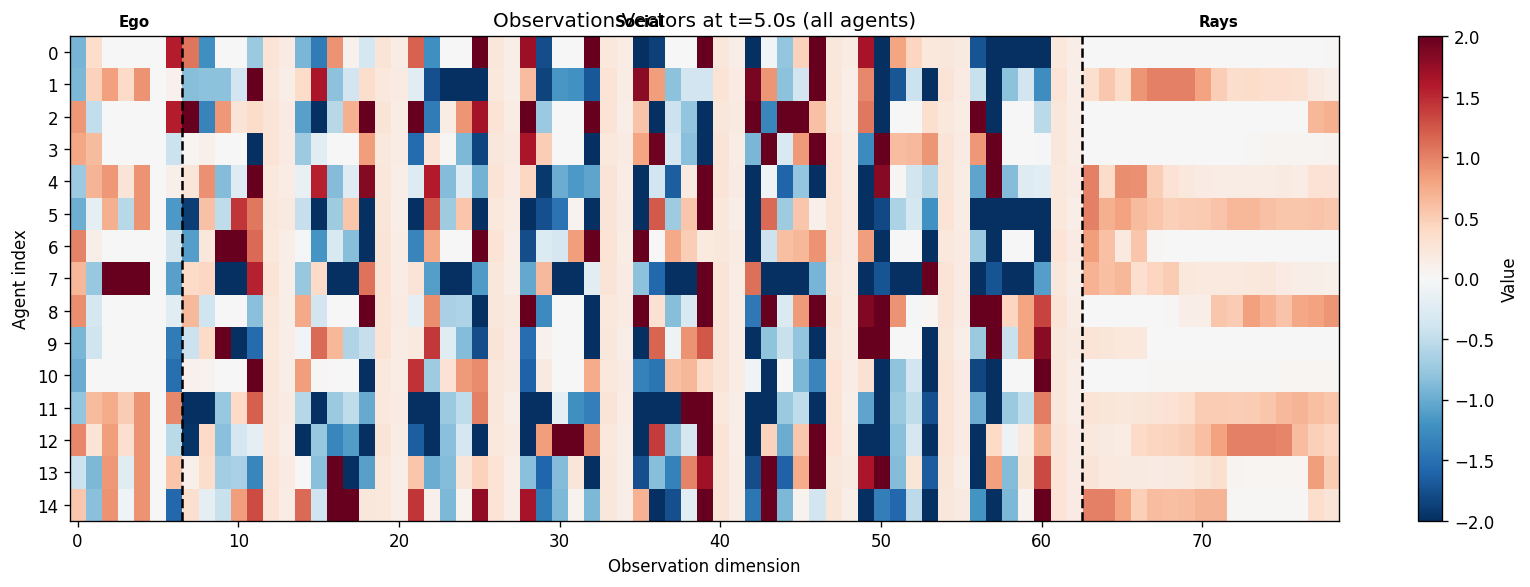

In [7]:
obs_snapshot = obs_history[50]  # Middle of simulation

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(obs_snapshot, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)

# Component boundaries
ego_end = 7
social_end = ego_end + obs_config.k_neighbours * 7

for boundary in [ego_end, social_end]:
    ax.axvline(boundary - 0.5, color="black", linewidth=1.5, linestyle="--")

ax.set_xlabel("Observation dimension")
ax.set_ylabel("Agent index")
ax.set_title("Observation Vectors at t=5.0s (all agents)")
ax.set_yticks(range(n_agents))

# Labels
ax.text(ego_end / 2, -0.8, "Ego", ha="center", fontsize=9, fontweight="bold")
ax.text((ego_end + social_end) / 2, -0.8, "Social", ha="center", fontsize=9, fontweight="bold")
ax.text((social_end + obs_config.obs_dim) / 2, -0.8, "Rays", ha="center", fontsize=9, fontweight="bold")

plt.colorbar(im, ax=ax, label="Value")
plt.tight_layout()
plt.show()

## What's Next?

This random-policy simulation demonstrates that the full pipeline works.
The next steps are:

1. **`crowdrl-train`**: Replace the random policy with MAPPO (PPO with parameter sharing)
2. **Tier 1 reward**: Goal bonus (+10), collision penalty (−1/step), timeout (−5)
3. **Tier 2 reward**: Jerk penalty, angular acceleration penalty, preferred-speed deviation
4. **Curriculum**: Start Tier 0 low-density, ramp up tier and agent count
5. **Export**: PyTorch → ONNX for deployment in JuPedSim